<a href="https://colab.research.google.com/github/davidlealo/practicos_sisrec_2026/blob/main/practico05/05_Hibridos_y_Ensambles_RespuestaDLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recomendadores Híbridos y Ensambles

En la práctica, ningún algoritmo de recomendación es perfecto. Los modelos basados en contenido entienden bien las características de los ítems, pero suelen recomendar cosas demasiado similares, los modelos colaborativos capturan patrones de interacción entre usuarios, pero sufren de cold start, y los modelos secuenciales o contextuales predicen la siguiente acción, pero no siempre captan la información global. Es por eso que los ensambles e híbridos surgen como una manera de abordar estas limitaciones.


**Profesor**: Denis Parra

**Ayudantes**: Javiera Azócar, Juan Manuel Hernandez, Nicolás Estévez, Pedro Palma, Alejandro Plaza

## Preliminares

### Librerías

In [1]:
!pip uninstall -y numpy scikit-surprise
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 26.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.2 requires 

In [1]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=7d8222f074e1c64f6369a89a934c2aef57264a6069d76b9f04eb82654b6b1007
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [2]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 11.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554977 sha256=86a4388bed986f71fdd94cb542398a5bdff9a32e600dfe2f3e92238b63f9b56a
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [3]:
!pip install gdown

In [4]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, KNNWithMeans, SVD
from surprise.model_selection import train_test_split
from math import sqrt
from sklearn.metrics import mean_squared_error

### Descargando los datasets

In [5]:
!gdown 15Y164QnWdmus9QBHWBCwyYezMACZsx-h

Downloading...
From: https://drive.google.com/uc?id=15Y164QnWdmus9QBHWBCwyYezMACZsx-h
To: /content/u2.base
100% 1.58M/1.58M [00:00<00:00, 19.1MB/s]


In [6]:
!gdown 1lSlGE1daKvGqg6-nUcMzT9lJK66HPZEJ

Downloading...
From: https://drive.google.com/uc?id=1lSlGE1daKvGqg6-nUcMzT9lJK66HPZEJ
To: /content/u2.test
100% 395k/395k [00:00<00:00, 13.6MB/s]


In [7]:
!gdown 13afMOhZGgIKLz784biKbvZ1rnM4iJzLk

Downloading...
From: https://drive.google.com/uc?id=13afMOhZGgIKLz784biKbvZ1rnM4iJzLk
To: /content/u.item
100% 236k/236k [00:00<00:00, 25.0MB/s]


### Procesamiento inicial de los datos

In [8]:
# Cargar MovieLens 100k
ratings = pd.read_csv("u2.base", sep="\t", names=["user_id", "item_id", "rating", "timestamp"])
ratings.head()

,user_id,item_id,rating,timestamp
0,1,3,4,878542960
1,1,4,3,876893119
2,1,5,3,889751712
3,1,6,5,887431973
4,1,7,4,875071561


In [9]:
columns = ['movieid', 'title', 'release_date', 'video_release_date', \
           'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', \
           'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', \
           'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', \
           'Thriller', 'War', 'Western']

pd.options.display.max_columns = None


movies = pd.read_csv('u.item', sep='|', index_col = 0, names = columns, header=None, encoding='latin-1')
movies.head()

,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieid,,,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [10]:
# Cargamos el dataset de testing
df_test = pd.read_csv('u2.test',
                      sep='\t',
                      names=['userid', 'itemid', 'rating', 'timestamp'],
                      header=None)


# rating >= 3 es relevante (1) y rating menor a 3 es no relevante (0)
df_test.rating = [1 if x >=3 else 0 for x in df_test.rating ]

# Guardamos los ítems relevantes para los usuarios
user_items_test = {}

for row in df_test.itertuples():
    if row[1] not in user_items_test:
        user_items_test[row[1]] = []

    user_items_test[row[1]].append(row[2])

In [11]:
# Mapear a índices internos
user_ids = ratings['user_id'].unique()
item_ids = ratings['item_id'].unique()

user_mapping = {u: i for i, u in enumerate(user_ids)}
item_mapping = {m: i for i, m in enumerate(item_ids)}
reverse_item_mapping = {v: k for k, v in item_mapping.items()}

ratings_m = ratings.copy()
ratings_m['user_idx'] = ratings_m['user_id'].map(user_mapping)
ratings_m['item_idx'] = ratings_m['item_id'].map(item_mapping)

num_users = len(user_mapping)
num_items = len(item_mapping)
print(f"Users: {num_users}  |  Items: {num_items}")

Users: 943  |  Items: 1648


### Definición de Métricas

In [12]:
# Definicion de métricas (No editar)

def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()

def average_precision_at_k(r, k):
    r = np.asarray(r)
    n_rel = r.sum() # Número de items relevantes
    if n_rel == 0:
        return 0.
    vectorized_precision = np.vectorize(lambda i: precision_at_k(r, i))
    indices = np.arange(1, len(r) + 1)
    precisions = vectorized_precision(indices) # Precision@k por cada posición del ranking
    score = np.sum(precisions * r)
    return score / min(k, n_rel)

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.


def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)

    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

## Modelo 1: Feedback Implícito + Contenido

ALS nos permite generar recomendaciones a partir de **feedback implícito** obtenido de las interacciones entre usuarios e ítems. Sin embargo, este enfoque puede enriquecerse incorporando otras características disponibles en el dataset.

En el caso de MovieLens, contamos con los títulos de las películas, que pueden aprovecharse como **información adicional basada en contenido** para complementar el recomendador y mejorar la calidad de las sugerencias.

**Pregunta 1** (2pts): ¿Cuál es la diferencia entre un modelo híbrido y un ensamble?

**Respuesta**:

Aunque estos dos modelos pueden tender a confundirse porque combinan distintos enfoques tienen una diferencia clara. El modelo híbrido combina distintas técnicas o paradigmas de recomendación, por ejemplo de filtrado por usuarios y el por contenido. En cambio, el modelo de ensamble funciona como los algoritmos de machine learning que combinan los outputs de distintos modelos para mejorar las métricas (como Bagging o Boosting).  

Para crear el modelo primero se generará una instancia para los modelos que se desean utilizar por separado.

In [13]:
# Crear matriz dispersa user-item
matrix = csr_matrix(
    (ratings_m['rating'].astype(np.float32),
     (ratings_m['user_idx'], ratings_m['item_idx'])),
    shape=(num_users, num_items),
    dtype=np.float32
)

In [14]:
# Entrenar modelo ALS (Collaborative Filtering)
als_model = AlternatingLeastSquares(factors=50, regularization=0.1, iterations=20)
als_model.fit(matrix)

# Modelo de contenido basado en géneros (o descripciones)
# Para MovieLens 100k, los géneros están codificados; aquí simplificamos usando títulos
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['title'].fillna(''))
content_sim = cosine_similarity(tfidf_matrix)

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

Una vez se tiene entrenados ambos modelos, se pueden combinar los puntajes que estos asignan para los pares usuario-ítem para generar un puntaje que utilizará nuestro recomendador.

In [15]:
# Función híbrida: combina ALS y contenido
def hybrid_score(user_idx, item_idx, alpha=0.7):
    # Score ALS
    als_score = als_model.user_factors[user_idx].dot(als_model.item_factors[item_idx])

    # Score contenido: promedio de similitudes con ítems que el usuario ya ha visto
    user_items = ratings[ratings['user_id'] == user_idx]['item_id'].values
    if len(user_items) == 0:
        content_score = 0
    else:
        content_score = content_sim[item_idx, user_items].mean()

    # Combinar con peso alpha
    return alpha * als_score + (1 - alpha) * content_score

# Generar recomendaciones híbridas
def recommend_hybrid(user_id, top_n=10, alpha=0.7):
    if user_id not in user_mapping:
        raise ValueError("Usuario no encontrado.")

    user_idx = user_mapping[user_id]

    if user_idx >= als_model.user_factors.shape[0]:
        raise ValueError(f"Índice de usuario {user_idx} fuera de rango. Máximo permitido: {als_model.user_factors.shape[0] - 1}")

    # Ítems que el usuario ya vio
    seen_items = set(ratings[ratings['user_id'] == user_id]['item_id'].values)

    # Todos los índices de ítems válidos
    all_item_indices = [i for i in item_mapping.values() if i not in seen_items]

    # Calcular scores híbridos
    scores = [(i_idx, hybrid_score(user_idx, i_idx, alpha)) for i_idx in all_item_indices]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Tomar los top-N y mapear a IDs originales
    top_items = scores[:top_n]

    recommended = []
    for i_idx, score in top_items:
        original_id = reverse_item_mapping[i_idx]
        if original_id in movies.index:
            title = movies.loc[original_id]['title']
            recommended.append((i_idx, title, score))

    return recommended


In [16]:
print(recommend_hybrid(1, top_n=5, alpha=0.7))

[(379, '2001: A Space Odyssey (1968)', 0.8022308945655823), (302, 'Sneakers (1992)', 0.7971147060394287), (9, 'Postino, Il (1994)', 0.7926077604293823), (158, 'Nikita (La Femme Nikita) (1990)', 0.766576623916626), (646, 'Dave (1993)', 0.7610671520233154)]


In [17]:
mean_ap = 0. # o MAP
mean_ndcg = 0.
for user_id in user_items_test.keys():
  rec_list = recommend_hybrid(user_id, top_n=10, alpha=0.7)
  rel_vector = [1 if item in user_items_test[user_id] else 0 for item in rec_list[0]]
  mean_ap += average_precision_at_k(rel_vector, 10)
  mean_ndcg += ndcg_at_k(rel_vector, 10)

mean_ap /= len(user_items_test)
mean_ndcg /= len(user_items_test)

print(f"MAP: {mean_ap}")
print(f"NDCG: {mean_ndcg}")

MAP: 0.03522205206738132
NDCG: 0.03522205206738132


**Pregunta 2 (6 pts)**: Prueba varios valores de alpha para generar las recomendaciones, grafiqua métricas y comenta los resultados.

**Respuesta**:

In [18]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
map_scores = []
ndcg_scores = []

In [19]:
print('Evaluando los valores de alpha')

for alpha in alphas:
    mean_ap = 0.0
    mean_ndcg = 0.0
    n_users = len(user_items_test)

    for user_id in user_items_test.keys():
        try:
            rec_list = recommend_hybrid(user_id, top_n=10, alpha=alpha)
            recommended_items = [item[0] for item in rec_list]

            rel_vector = [1 if item in user_items_test[user_id] else 0
                          for item in recommended_items]

            mean_ap += average_precision_at_k(rel_vector, 10)
            mean_ndcg += ndcg_at_k(rel_vector, 10)

        except:
            continue

    mean_ap /= n_users
    mean_ndcg /= n_users

    map_scores.append(mean_ap)
    ndcg_scores.append(mean_ndcg)

    print(f"alpha = {alpha:.1f} → MAP@10 = {mean_ap:.4f} | NDCG@10 = {mean_ndcg:.4f}")

Evaluando los valores de alpha
alpha = 0.0 → MAP@10 = 0.1079 | NDCG@10 = 0.1511
alpha = 0.2 → MAP@10 = 0.1067 | NDCG@10 = 0.1704
alpha = 0.4 → MAP@10 = 0.1028 | NDCG@10 = 0.1634
alpha = 0.6 → MAP@10 = 0.1015 | NDCG@10 = 0.1602
alpha = 0.8 → MAP@10 = 0.1036 | NDCG@10 = 0.1625
alpha = 1.0 → MAP@10 = 0.1033 | NDCG@10 = 0.1625


In [20]:
import matplotlib.pyplot as plt

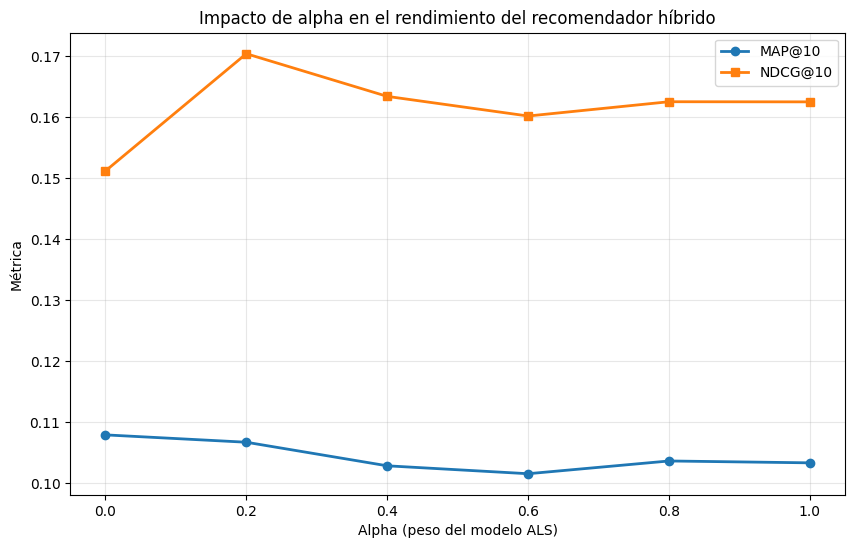

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, map_scores, marker='o', label='MAP@10', linewidth=2)
plt.plot(alphas, ndcg_scores, marker='s', label='NDCG@10', linewidth=2)

plt.xlabel('Alpha (peso del modelo ALS)')
plt.ylabel('Métrica')
plt.title('Impacto de alpha en el rendimiento del recomendador híbrido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(alphas)
plt.show()

Evalué valores desde 0 a 1 tomando los pares. Donde Alpha es el valor que fui cambiando para el ALS.

El peor rendimiento se obtiene en alpha = 0.0, con un NDCG@10 de 0.1511. Esto era esperable, ya que el modelo de contenido actual solo utiliza los títulos de las películas, lo cual es una característica débil para capturar similitud semántica.

El mejor rendimiento se observa en alpha = 0.2, alcanzando el valor más alto de NDCG@10 (0.1704) al igual que de MAP@10 (0.1067). Esto indica que una combinación donde el modelo ALS tiene un peso moderado y el contenido un peso alto produce las mejores recomendaciones en este experimento.

## Modelos 2: Feedback Explícito, Factores Latentes y Contenido

Ahora generaremos un modelo más completo al utilizar información explícita, factores latentes y más features de contenido. Al combinar estos tres enfoques en un modelo híbrido/ensamble, buscamos integrar lo mejor de cada uno: la memoria de las similitudes, el poder predictivo de los factores latentes y la información adicional basada en contenido, obteniendo así recomendaciones más robustas y diversas. Es por eso que para esta parte combinaremos ItemKNN con FunkSVD y Content-based.

Primero preparamos el reader de surprise para poder cargar los datos en el formato de la librería.

In [22]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id','item_id','rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)

Posterior a esto, se entrena los modelos colaborativos que se desean utilizar.

In [23]:
sim_options = {"name": "cosine", "user_based": False}
iknn = KNNWithMeans(sim_options=sim_options)
iknn.fit(trainset)

# FunkSVD
svd = SVD()
svd.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


A continuación, volveremos a entrenar un modelo content-based, pero esta vez usando los géneros de las películas.

In [24]:
# matriz de géneros
genres = movies.drop(columns=['title','release_date','video_release_date','IMDb_URL'])
genre_matrix = genres.values
similarity_matrix = cosine_similarity(genre_matrix)

# dict para similitud content-based
item_sim_dict = {}
for i, movie in enumerate(movies.index):
    item_sim_dict[movie] = {}
    for j, movie2 in enumerate(movies.index):
        if i != j:
            item_sim_dict[movie][movie2] = similarity_matrix[i, j]

Predicciones por modelo

In [25]:
pred_iknn = {}
pred_funksvd = {}

# Inicializar diccionarios
for u in ratings['user_id'].unique():
    pred_iknn[u] = {}
    pred_funksvd[u] = {}
    #pred_content[u] = {}

# predicciones KNN y SVD
for (u, i, r) in testset:
    uid, iid = int(u), int(i)

    # iKNN
    pred_iknn[uid][iid] = iknn.predict(uid, iid).est

    # FunkSVD
    pred_funksvd[uid][iid] = svd.predict(uid, iid).est

In [26]:
# medias por usuario
user_hist = ratings.groupby("user_id")["item_id"].apply(list).to_dict()
user_ratings = ratings.groupby(["user_id","item_id"])["rating"].mean().to_dict()
user_mean = {u: np.mean([r for (uu, _), r in user_ratings.items() if uu == u])
             for u in ratings['user_id'].unique()}

pred_content = {}

for u, items_rated in user_hist.items():
    pred_content[u] = {}
    for iid in movies.index:
        if (u, iid) not in user_ratings:  # no predecir vistos
            numerador, denominador = 0, 0

            # top-N ítems más similares
            if iid in item_sim_dict:
                top_sim_items = sorted(item_sim_dict[iid].items(), key=lambda x: x[1], reverse=True)[:20]

                for seen, sim in top_sim_items:
                    if (u, seen) in user_ratings:
                        numerador += sim * (user_ratings[(u, seen)] - user_mean[u])
                        denominador += abs(sim)

            if denominador > 0:
                pred_content[u][iid] = user_mean[u] + numerador / denominador
            else:
                pred_content[u][iid] = user_mean[u]  # fallback = promedio del usuario

In [27]:
user_mean = {
    u: np.mean([r for (uu, _), r in user_ratings.items() if uu == u])
    for u in ratings['user_id'].unique()
}

pred_content_full = {}
for u in ratings['user_id'].unique():
    pred_content_full[u] = {}
    for iid in movies.index:
        if iid in pred_content.get(u, {}):
            pred_content_full[u][iid] = pred_content[u][iid]
        elif (u, iid) in user_ratings:
            # si ya lo vio, usar el rating real
            pred_content_full[u][iid] = user_ratings[(u, iid)]
        else:
            # fallback: media del usuario
            pred_content_full[u][iid] = user_mean[u]

In [28]:
print(pred_funksvd[196][153])

KeyError: 153

In [35]:
# Veamos qué tipo de estructura es el interior
print(type(pred_funksvd[196]))

# Si resulta ser un diccionario, miremos cuáles son exactamente sus llaves
print(pred_funksvd[196].keys())

<class 'dict'>
dict_keys([762, 269, 242, 306])


In [36]:
print(pred_funksvd[196][762])

3.77226383347881


In [37]:
print(pred_iknn[196][762])

3.6988060102703413


In [38]:
print(pred_content_full[196][762])

3.0


Híbrido de ponderaición

In [39]:
w_iknn, w_funksvd, w_content = 0.3, 0.5, 0.2

def hybrid_predict(user, item):
    score_iknn = pred_iknn.get(user, {}).get(item, 0)
    score_funksvd = pred_funksvd.get(user, {}).get(item, 0)
    score_content = pred_content_full.get(user, {}).get(item, 0)

    return (w_iknn * score_iknn +
            w_funksvd * score_funksvd +
            w_content * score_content)

Evaluación RMSE

In [40]:
def evaluate_model(predictor, testset):
    y_true, y_pred = [], []
    for uid, iid, r in testset:
        y_true.append(r)

        # Si predictor es función -> llámala
        if callable(predictor):
            y_pred.append(predictor(uid, iid))
        else:  # Si es diccionario -> busca con .get
            y_pred.append(predictor.get(uid, {}).get(iid, 0))

    rmse = sqrt(mean_squared_error(y_true, y_pred))
    return rmse

rmse_iknn = evaluate_model(pred_iknn, testset)
rmse_svd = evaluate_model(pred_funksvd, testset)
rmse_content = evaluate_model(pred_content, testset)
rmse = evaluate_model(hybrid_predict, testset)

print("RMSE iKNN:", rmse_iknn)
print("RMSE FunkSVD:", rmse_svd)
print("RMSE Content-Based:", rmse_content)
print("RMSE Híbrido:", rmse)

RMSE iKNN: 0.9486835096735632
RMSE FunkSVD: 0.9448478702216798
RMSE Content-Based: 3.7012329026960735
RMSE Híbrido: 0.7497225045910385


Precisión@K

In [41]:
def precision_at_k_model(user_id, pred_dict, k=10):
    if user_id not in pred_dict:
        return 0

    items_scores = [(iid, pred_dict[user_id].get(iid, 0)) for iid in movies.index]
    ranked = sorted(items_scores, key=lambda x: x[1], reverse=True)[:k]

    relevant = [iid for (uid,iid),r in user_ratings.items() if uid==user_id and r>=4]
    recommended = [iid for iid,_ in ranked]

    hits = len(set(recommended) & set(relevant))
    return hits/k


pred_hybrid = {
    u: {i: hybrid_predict(u, i) for i in movies.index}
    for u in ratings['user_id'].unique()
}
# calcular precision promedio
precision_iknn = np.mean([precision_at_k_model(u, pred_iknn) for u in ratings['user_id'].unique()])
precision_svd = np.mean([precision_at_k_model(u, pred_funksvd) for u in ratings['user_id'].unique()])
precision_content = np.mean([
    precision_at_k_model(u, pred_content_full) for u in ratings['user_id'].unique()
])
precision_hybrid = np.mean([precision_at_k_model(u, pred_hybrid) for u in ratings['user_id'].unique()])

print("Precision@10 iKNN:", precision_iknn)
print("Precision@10 FunkSVD:", precision_svd)
print("Precision@10 Content-Based:", precision_content)
print("Precision@10 Híbrido:", precision_hybrid)

Precision@10 iKNN: 0.5222693531283139
Precision@10 FunkSVD: 0.5205726405090138
Precision@10 Content-Based: 0.40148462354188763
Precision@10 Híbrido: 0.6111346765641569


**Pregunta 3** (10 pts): Implemente un modelo híbrido o ensamble distinto a los vistos en este práctico (puede ser sencillo). Genere listas de recomendación con su modelo y con sus modelos base y comente ¿Su modelo fue mejor o peor que usar los modelos por separado? ¿Por qué cree que pudo haber ocurrido esto?

In [43]:
# COMPLETAR

w_iknn, w_funksvd, w_content = 0.5, 0.2, 0.3

# Evaluación RMSE
rmse_iknn = evaluate_model(pred_iknn, testset)
rmse_svd = evaluate_model(pred_funksvd, testset)
rmse_content = evaluate_model(pred_content, testset)
rmse = evaluate_model(hybrid_predict, testset)

print("RMSE iKNN:", rmse_iknn)
print("RMSE FunkSVD:", rmse_svd)
print("RMSE Content-Based:", rmse_content)
print("RMSE Híbrido:", rmse)

RMSE iKNN: 0.9486835096735632
RMSE FunkSVD: 0.9448478702216798
RMSE Content-Based: 3.7012329026960735
RMSE Híbrido: 0.6577556910846974


In [45]:
# Evaluación Precisión@K
pred_hybrid = {
    u: {i: hybrid_predict(u, i) for i in movies.index}
    for u in ratings['user_id'].unique()
}
# calcular precision promedio
precision_iknn = np.mean([precision_at_k_model(u, pred_iknn) for u in ratings['user_id'].unique()])
precision_svd = np.mean([precision_at_k_model(u, pred_funksvd) for u in ratings['user_id'].unique()])
precision_content = np.mean([
    precision_at_k_model(u, pred_content_full) for u in ratings['user_id'].unique()
])
precision_hybrid = np.mean([precision_at_k_model(u, pred_hybrid) for u in ratings['user_id'].unique()])

print("Precision@10 iKNN:", precision_iknn)
print("Precision@10 FunkSVD:", precision_svd)
print("Precision@10 Content-Based:", precision_content)
print("Precision@10 Híbrido:", precision_hybrid)

Precision@10 iKNN: 0.5222693531283139
Precision@10 FunkSVD: 0.5205726405090138
Precision@10 Content-Based: 0.40148462354188763
Precision@10 Híbrido: 0.6268292682926829


In [46]:
num_usuarios = ratings['user_id'].nunique()
num_items = ratings['item_id'].nunique()
total_ratings = len(ratings)
posibles_ratings = num_usuarios * num_items

esparcidad = 1 - (total_ratings / posibles_ratings)
print(f"La esparcidad de la matriz es: {esparcidad:.4%} (Mientras más cerca a 100%, más difícil es para el modelo colaborativo)")

La esparcidad de la matriz es: 94.8522% (Mientras más cerca a 100%, más difícil es para el modelo colaborativo)


In [49]:
umbral_cold_start = 20
calificaciones_por_usuario = ratings.groupby('user_id').size()
usuarios_frios = (calificaciones_por_usuario < umbral_cold_start).sum()
pct_usuarios_frios = usuarios_frios / num_usuarios
print(f"Usuarios en Cold Start (<{umbral_cold_start} ratings): {usuarios_frios} ({pct_usuarios_frios:.2%})")

Usuarios en Cold Start (<20 ratings): 108 (11.45%)


In [50]:
umbral_cold_start = 10
calificaciones_por_item = ratings.groupby('item_id').size()
items_frios = (calificaciones_por_item < umbral_cold_start).sum()
pct_items_frios = items_frios / num_items
print(f"Ítems en Cold Start (<{umbral_cold_start} ratings): {items_frios} ({pct_items_frios:.2%})")

Ítems en Cold Start (<10 ratings): 559 (33.92%)


Primero intenté modificando los parámetros, haciendo una optimización y efectivamente cambiaron las métricas. Pero de todas formas como la instrucción era probar un nuevo enfoque, pensé que uno de los posibles problemas es el de Cold Start y por eso las pruebas anteriores.

Como ya sabíamos de antes, el sparsity es alto (como regularmente pasa en estas base de datos de recomendación). La sparsity es del 94.85%. Más importante aún, detecté que el 11.45% de los usuarios y el 33.92% del catálogo de películas se encuentran en zona de Cold Start.

Debido a esto, voy a implementar un Híbrido por Conmutación (Switching) con un umbral de 20 interacciones

In [52]:
experimento_umbral = 20

In [53]:
def switching_hybrid_predict(user, item):
    num_interacciones = len(user_hist.get(user, []))

    if num_interacciones < experimento_umbral:
        return pred_content_full.get(user, {}).get(item, 0)

    else:
        return pred_funksvd.get(user, {}).get(item, 0)

pred_switching = {
    u: {i: switching_hybrid_predict(u, i) for i in movies.index}
    for u in ratings['user_id'].unique()
}

precision_switching = np.mean([precision_at_k_model(u, pred_switching) for u in ratings['user_id'].unique()])

print("--- Comparativa de Precision@10 ---")
print("Precision@10 iKNN base:", precision_iknn)
print("Precision@10 FunkSVD base:", precision_svd)
print("Precision@10 Content-Based base:", precision_content)
print(f"Precision@10 Switching Híbrido (Umbral={experimento_umbral}):", precision_switching)

--- Comparativa de Precision@10 ---
Precision@10 iKNN base: 0.5222693531283139
Precision@10 FunkSVD base: 0.5205726405090138
Precision@10 Content-Based base: 0.40148462354188763
Precision@10 Switching Híbrido (Umbral=20): 0.5116648992576882


In [54]:
umbrales = [0, 5, 10, 15, 20, 30]

print("Evaluando distintos umbrales para el Switching Hybrid:")

for umbral in umbrales:
    def temp_switching_predict(user, item):
        num_interacciones = len(user_hist.get(user, []))
        if num_interacciones < umbral:
            return pred_content_full.get(user, {}).get(item, 0)
        else:
            return pred_funksvd.get(user, {}).get(item, 0)

    temp_pred_switching = {
        u: {i: temp_switching_predict(u, i) for i in movies.index}
        for u in ratings['user_id'].unique()
    }

    precision = np.mean([precision_at_k_model(u, temp_pred_switching) for u in ratings['user_id'].unique()])
    print(f"Umbral {umbral:>2} | Precision@10 = {precision:.4f}")

Evaluando distintos umbrales para el Switching Hybrid:
Umbral  0 | Precision@10 = 0.5206
Umbral  5 | Precision@10 = 0.5206
Umbral 10 | Precision@10 = 0.5207
Umbral 15 | Precision@10 = 0.5193
Umbral 20 | Precision@10 = 0.5117
Umbral 30 | Precision@10 = 0.4900


In [55]:
experimento_umbral = 10

In [56]:
pred_switching = {
    u: {i: switching_hybrid_predict(u, i) for i in movies.index}
    for u in ratings['user_id'].unique()
}

precision_switching = np.mean([precision_at_k_model(u, pred_switching) for u in ratings['user_id'].unique()])

print("--- Comparativa de Precision@10 ---")
print("Precision@10 iKNN base:", precision_iknn)
print("Precision@10 FunkSVD base:", precision_svd)
print("Precision@10 Content-Based base:", precision_content)
print(f"Precision@10 Switching Híbrido (Umbral={experimento_umbral}):", precision_switching)

--- Comparativa de Precision@10 ---
Precision@10 iKNN base: 0.5222693531283139
Precision@10 FunkSVD base: 0.5205726405090138
Precision@10 Content-Based base: 0.40148462354188763
Precision@10 Switching Híbrido (Umbral=10): 0.5206786850477201


Con este modelo intenté tratar de disminuir el impacto del cold start, mejorando un poco el resultado comparado con FunkSVD base

**Uso de IA** La usé porque no entendía el error y no me recordaba los métodos de diccionario. AHí la conversación: https://gemini.google.com/share/cbcdfc4b41fd